В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

# Імпорт бібліотек

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
!pip install pyarrow --quiet

In [3]:
import opendatasets as od
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc, accuracy_score
import joblib

In [4]:
dataset_url = 'https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction'

In [5]:
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: oleksandrderenivskyi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction


100%|██████████| 262k/262k [00:00<00:00, 463MB/s]

In [6]:
data_dir = './bank-customer-churn-prediction'

In [7]:
os.listdir(data_dir)

['Churn_Modelling.csv']

In [8]:
train_csv = data_dir + '/Churn_Modelling.csv'

In [9]:
raw_df = pd.read_csv(train_csv)

In [10]:
raw_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [11]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [12]:
input_cols = raw_df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1).columns.to_list()
target_col = 'Exited'

In [13]:
train_inputs, val_inputs, train_targets, val_targets  = train_test_split(raw_df[input_cols], raw_df[target_col], test_size=0.2, random_state=17)

In [14]:
print('train_inputs.shape :', train_inputs.shape)
print('train_targets.shape :', train_targets.shape)
print('val_inputs.shape :', val_inputs.shape)
print('val_targets.shape :', val_targets.shape)

train_inputs.shape : (8001, 10)
train_targets.shape : (8001,)
val_inputs.shape : (2001, 10)
val_targets.shape : (2001,)


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [15]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [16]:
numeric_cols

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [17]:
categorical_cols

['Geography', 'Gender']

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [18]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,8001.00,8000.00,8001.0,8001.00,8001.00,8000.00,8000.00,8001.00
mean,650.44,38.93,5.0,76966.50,1.53,0.71,0.52,99685.97
std,96.85,10.48,2.9,62410.40,0.58,0.46,0.50,57627.31
min,350.00,18.00,0.0,0.00,1.00,0.00,0.00,11.58
25%,583.00,32.00,2.0,0.00,1.00,0.00,0.00,49915.52
50%,652.00,37.00,5.0,97325.15,1.00,1.00,1.00,99449.86
75%,718.00,44.00,8.0,128173.90,2.00,1.00,1.00,148993.47
max,850.00,92.00,10.0,250898.09,4.00,1.00,1.00,199992.48


# Заповнення пропущених значень для числових ознак

In [19]:
train_inputs[numeric_cols].isna().sum()

,0
CreditScore,0
Age,1
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,1
IsActiveMember,1
EstimatedSalary,0


In [20]:
numeric_imputer = SimpleImputer(strategy = 'mean')

In [21]:
numeric_imputer.fit(train_inputs[numeric_cols])

SimpleImputer()

In [22]:
list(numeric_imputer.statistics_)

[np.float64(650.4424446944132),
 np.float64(38.9315975),
 np.float64(5.004124484439445),
 np.float64(76966.50167479066),
 np.float64(1.5285589301337332),
 np.float64(0.70675),
 np.float64(0.515625),
 np.float64(99685.96630046243)]

In [23]:
train_inputs[numeric_cols] = numeric_imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = numeric_imputer.transform(val_inputs[numeric_cols])

In [24]:
train_inputs[numeric_cols].isna().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


# Заповнення пропущених значень для категорійних ознак

In [25]:
train_inputs[categorical_cols].isna().sum()

,0
Geography,1
Gender,0


In [26]:
categorical_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

In [27]:
categorical_imputer.fit(train_inputs[categorical_cols])

SimpleImputer(fill_value='Unknown', strategy='constant')

In [28]:
train_inputs[categorical_cols] = categorical_imputer.transform(train_inputs[categorical_cols])
val_inputs[categorical_cols] = categorical_imputer.transform(val_inputs[categorical_cols])

In [29]:
train_inputs[categorical_cols].isna().sum()

,0
Geography,0
Gender,0


# Масштабування числових ознак

In [30]:
scaler = MinMaxScaler()

In [31]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

In [32]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# Кодування категоріальних даних

In [33]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [34]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [35]:
encoder.categories_

[array(['France', 'Germany', 'Spain', 'Unknown'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

In [36]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Geography_Unknown', 'Gender_Female', 'Gender_Male']


In [37]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [38]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [39]:
!ls

bank-customer-churn-prediction	train_inputs.parquet   val_inputs.parquet
sample_data			train_targets.parquet  val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [40]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [41]:
model = LogisticRegression(solver='liblinear')

In [42]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [43]:
train_preds = model.predict(X_train)

In [44]:
val_preds = model.predict(X_val)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [45]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

array([0, 0, 1, ..., 0, 1, 0])

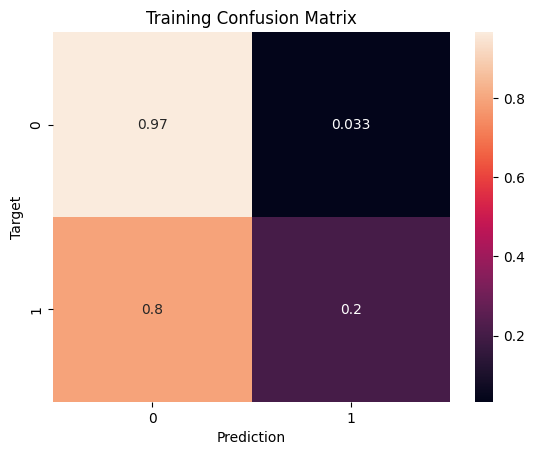

In [46]:
predict_and_plot(X_train, train_targets, 'Training')

array([0, 0, 0, ..., 0, 0, 0])

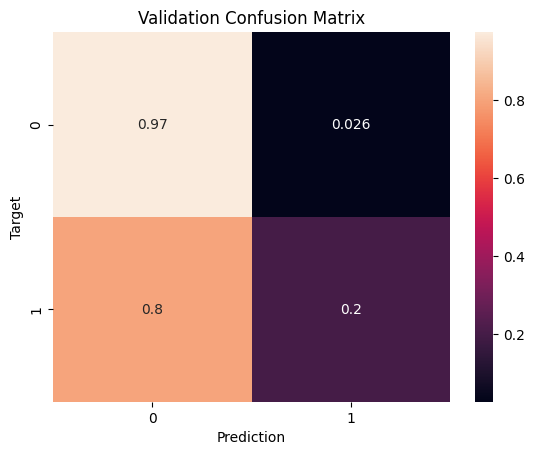

In [47]:
predict_and_plot(X_val, val_targets, 'Validation')

In [48]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.77


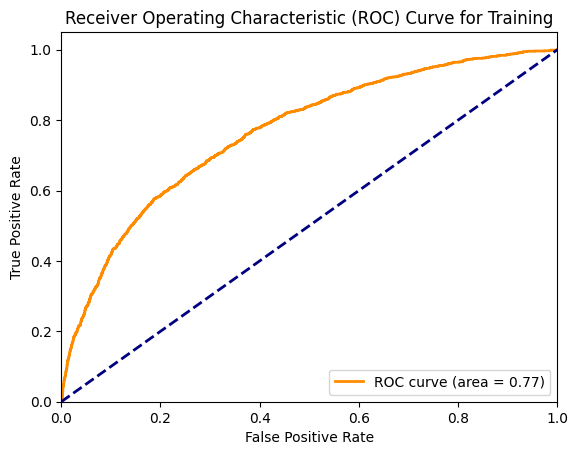

AUROC for Validation: 0.77


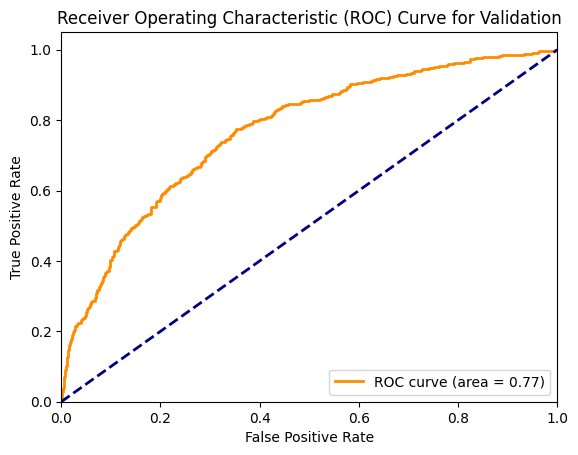

In [49]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [50]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 0.31%
F1 score Validation: 0.31%


На мою думку якісь моделі задовільна, так як метрика AUROC для навчального і валідаційного набору даних = 0.77, що є хорошим значенням, а метрика F1 Score 0.31, що вказує на те, що модель погано класифікує клас 1. Ймовірно це через дизбаланс класів

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [51]:
train_targets.value_counts()

,count
Exited,
0,6369
1,1632


In [52]:
accuracy_score(train_targets, train_preds), accuracy_score(val_targets, val_preds)

(0.8118985126859143, 0.816591704147926)

In [53]:
def all_0(inputs):
  return np.full(len(inputs), 0)

In [54]:
accuracy_score(train_targets, all_0(X_train)), accuracy_score(val_targets, all_0(X_val))

(0.7960254968128984, 0.7971014492753623)

Я б тут теж її оцінив задовільно, так як метрика Accuracy 0,81, а метрика моделі, яка завжди прогнозує клас 0 - 0,79, хоч вони і дуже близькі, але все ж наша модель має трішки вищу точність

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [55]:
Bank_customer_churn = {
    'model': model,
    'numeric_imputer': numeric_imputer,
    'categorical_imputer': categorical_imputer,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [56]:
joblib.dump(Bank_customer_churn, 'log_reg.joblib')

['log_reg.joblib']

In [57]:
model_2 = joblib.load('log_reg.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [58]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(numeric_imputer, categorical_imputer, scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df[numeric_cols] = numeric_imputer.transform(input_df[numeric_cols])
    input_df[categorical_cols] = categorical_imputer.transform(input_df[categorical_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]
    return prob

In [59]:
predict_raw_df(numeric_imputer, categorical_imputer, scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.12172575, 0.15606037, 0.36098191, 0.24529947, 0.14946565])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [60]:
!kaggle competitions download -c bank-customer-churn-prediction-dlu-course-c-3 -f test.csv

  0% 0.00/783k [00:00<?, ?B/s]
100% 783k/783k [00:00<00:00, 801MB/s]


In [61]:
test_raw_df = pd.read_csv('/content/test.csv')

In [62]:
pred_exited = predict_raw_df(numeric_imputer, categorical_imputer, scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

In [63]:
test_raw_df['Exited'] = pred_exited

In [64]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Geography_Unknown,Gender_Female,Gender_Male,Exited
0,15000,15594796.0,Chu,0.468,Germany,Male,0.162162,0.2,0.582123,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,0.0,1.0,0.100722
1,15001,15642821.0,Mazzi,0.402,France,Male,0.283784,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,0.0,1.0,0.059224
2,15002,15716284.0,Onyekachi,0.712,France,Male,0.337838,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,0.0,1.0,0.181160
3,15003,15785078.0,Martin,0.734,Spain,Male,0.364865,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,0.0,1.0,0.090236
4,15004,15662955.0,Kenechukwu,0.484,Spain,Male,0.337838,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,0.0,1.0,0.075813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,0.578,Spain,Male,0.270270,1.0,0.000000,0.333333,1.0,1.0,0.248154,0.0,0.0,1.0,0.0,0.0,1.0,0.048527
9996,24996,15739271.0,Clements,0.656,Spain,Male,0.283784,0.9,0.000000,0.333333,1.0,1.0,0.712578,0.0,0.0,1.0,0.0,0.0,1.0,0.053705
9997,24997,15756743.0,Chidiebere,0.848,France,Male,0.162162,0.9,0.000000,0.333333,1.0,0.0,0.024253,1.0,0.0,0.0,0.0,0.0,1.0,0.070424
9998,24998,15680167.0,Yermakova,0.490,France,Male,0.270270,0.6,0.577429,0.000000,1.0,0.0,0.632348,1.0,0.0,0.0,0.0,0.0,1.0,0.213949


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [65]:
!kaggle competitions download -c bank-customer-churn-prediction-dlu-course-c-3 -f sample_submission.csv

  0% 0.00/97.7k [00:00<?, ?B/s]
100% 97.7k/97.7k [00:00<00:00, 348MB/s]


In [66]:
sample_submission = pd.read_csv('/content/sample_submission.csv')

In [67]:
sample_submission['Exited'] = test_raw_df['Exited']

In [68]:
sample_submission.head()

,id,Exited
0,15000,0.100722
1,15001,0.059224
2,15002,0.181160
3,15003,0.090236
4,15004,0.075813


In [69]:
output_path = '/content/submission_log_reg.csv'

In [70]:
sample_submission.to_csv(output_path, index=False)